# Notebook 34 — Posterior Calibration Root-Cause Audit

**Framing:** protocol-locked hypothesis-driven follow-up on the reused `powered_1024` diagnostic bank — **not** untouched confirmatory evaluation.

This notebook **only reads** precomputed artifacts under `results/figure10_8d_7d/artifacts/notebook_34/`. Expensive sampling is done by `python -m sleep_sbi.figure10_notebook34_audit`.

**Question:** For `mui` / `mue` / `tauA` calibration failure, do current offline evidence favor implementation/sampling (A), summary/identifiability (B), estimator/calibration (C), a controlled 131k pilot design (D), or inconclusive (E)?

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path("..").resolve()
N34 = ROOT / "results" / "figure10_8d_7d" / "artifacts" / "notebook_34"
JSON = N34 / "json"
CSV = N34 / "csv"
FIG = N34 / "figures"

required = [
    JSON / "protocol_lock.json",
    JSON / "phase0_integrity_report.json",
    JSON / "phase1_summary.json",
    JSON / "phase2_clip_audit_report.json",
    JSON / "decision_gate.json",
    CSV / "phase1_phenotype_all.csv",
    CSV / "attribution_matrix.csv",
    CSV / "final_action_go_nogo.csv",
]
missing = [p for p in required if not p.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing artifacts. Run from S4_sbi/src:\n"
        "  python -m sleep_sbi.figure10_notebook34_audit --phase all\n"
        + "\n".join(str(p) for p in missing)
    )

lock = json.loads((JSON / "protocol_lock.json").read_text(encoding="utf-8"))
p0 = json.loads((JSON / "phase0_integrity_report.json").read_text(encoding="utf-8"))
p1 = json.loads((JSON / "phase1_summary.json").read_text(encoding="utf-8"))
p2 = json.loads((JSON / "phase2_clip_audit_report.json").read_text(encoding="utf-8"))
p3 = json.loads((JSON / "phase3_summary.json").read_text(encoding="utf-8")) if (JSON / "phase3_summary.json").is_file() else {}
p4 = json.loads((JSON / "phase4_summary.json").read_text(encoding="utf-8")) if (JSON / "phase4_summary.json").is_file() else {}
gate = json.loads((JSON / "decision_gate.json").read_text(encoding="utf-8"))
ph1 = pd.read_csv(CSV / "phase1_phenotype_all.csv")
attr = pd.read_csv(CSV / "attribution_matrix.csv")
go = pd.read_csv(CSV / "final_action_go_nogo.csv")
print("Artifacts OK:", N34)

Artifacts OK: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d\artifacts\notebook_34


## Executive Decision Dashboard

In [2]:
sens = pd.read_csv(CSV / "phase3_sensitivity_oof.csv") if (CSV / "phase3_sensitivity_oof.csv").is_file() else None
focus = ph1[(ph1.n_train == 32768) & (ph1.parameter.isin(["mui", "mue", "tauA"]))]
ens = focus[focus.estimator == "ensemble"][["track", "parameter", "rank_mean", "central_cov_90", "pit_ecdf_ks", "bias_unit"]]

lines = [
    "| # | Item | Status |",
    "|---|------|--------|",
    f"| 1 | Integrity audit | **{p0['integrity_gate']}** ({p0['n_passed']}/{p0['n_tests']} tests) |",
    f"| 2 | Clipping sensitivity | **{p2.get('clip_sensitivity', '?')}** |",
    f"| 3 | Focus-parameter failure phenotype | see table below (reused bank follow-up) |",
    f"| 4 | Summary informativeness | OOF ExtraTrees vs prior-mean baseline (Phase 3) |",
    f"| 5 | Joint diagnostic | Gaussian-moment only (not joint SBC / general CR coverage) |",
    f"| 6 | Primary action | **`{gate['primary_action']}`** |",
    f"| 7 | Secondary mechanisms | {', '.join(gate.get('secondary_supported_mechanisms') or ['—'])} |",
    f"| 8 | 131k / 1M | **{gate.get('pilot_131k_status','NO-GO')}** / **{gate.get('scale_1M_status','NO-GO')}** |",
]
display(Markdown("\n".join(lines)))
display(Markdown("### Top 3 evidence"))
for i, e in enumerate(gate.get("top_evidence", []), 1):
    display(Markdown(f"{i}. {e}"))
display(Markdown("### Top 3 limitations"))
for i, e in enumerate(gate.get("top_limitations", []), 1):
    display(Markdown(f"{i}. {e}"))
display(Markdown("### Focus phenotype (ensemble @32768, equal-tailed from ranks — not HPD/HDI)"))
display(ens.sort_values(["parameter", "track"]).reset_index(drop=True))

| # | Item | Status |
|---|------|--------|
| 1 | Integrity audit | **PASS** (39/39 tests) |
| 2 | Clipping sensitivity | **material** |
| 3 | Focus-parameter failure phenotype | see table below (reused bank follow-up) |
| 4 | Summary informativeness | OOF ExtraTrees vs prior-mean baseline (Phase 3) |
| 5 | Joint diagnostic | Gaussian-moment only (not joint SBC / general CR coverage) |
| 6 | Primary action | **`A_IMPLEMENTATION_FIX_FIRST`** |
| 7 | Secondary mechanisms | clipping_strategy_material, after_A_fix_C_likely: summaries_informative_and_stable_member_miscalibration |
| 8 | 131k / 1M | **NO-GO** / **NO-GO** |

### Top 3 evidence

1. Phase0 integrity gate=PASS (failed_critical=0)

2. Phase2 clip sensitivity=material

3. Focus OOF ExtraTrees R2: mue[8d]=0.607, mui[8d]=0.987, tauA[8d]=0.366, mue[7d]=0.606, mui[7d]=0.987, tauA[7d]=0.367

...

1. powered_1024 is a reused diagnostic bank, not sealed confirmatory evaluation

2. 8192 vs 32768 is an asymmetric descriptive contrast (1 vs 5 estimators), not a causal n_sim effect

3. Phase 2/4 use matched 48 cases × 512 draws; ranks/PIT are equal-tailed from samples, not HPD/HDI

### Focus phenotype (ensemble @32768, equal-tailed from ranks — not HPD/HDI)

,track,parameter,rank_mean,central_cov_90,pit_ecdf_ks,bias_unit
0,7d,mue,0.518899,0.827148,0.076663,-0.012004
1,8d,mue,0.520694,0.834961,0.071578,-0.017265
2,7d,mui,0.460755,0.986328,0.184393,0.001225
3,8d,mui,0.589638,0.982422,0.252459,-0.002453
4,7d,tauA,0.520424,0.831055,0.070354,-0.011323
5,8d,tauA,0.524684,0.832031,0.072194,-0.019171


## Phase 0 — Protocol lock & integrity

Gate must be PASS before treating B/C/D as causal root causes.

In [3]:
budget = lock["sampling"]["budget_arithmetic"]
display(Markdown(
    f"**Integrity:** `{p0['integrity_gate']}`  \n"
    f"**Rank normalize:** `{lock['rank_definition']['protocol_locked']['normalize']}` "
    f"(matches N33 legacy; randomized ties, not midpoint)  \n"
    f"**Phase2/4 draw budget:** member={budget['member_draws']:,} + ensemble={budget['ensemble_draws']:,} "
    f"= **{budget['total_draws']:,}**  \n"
    f"**Science framing:** {lock['science_framing']}"
))
failed = p0.get("failed_critical") or []
if failed:
    display(pd.DataFrame(failed))
else:
    display(Markdown("No critical integrity failures."))

**Integrity:** `PASS`  
**Rank normalize:** `(rank_randomized + 0.5) / (n_samples + 1)` (matches N33 legacy; randomized ties, not midpoint)  
**Phase2/4 draw budget:** member=245,760 + ensemble=49,152 = **294,912**  
**Science framing:** protocol-locked hypothesis-driven follow-up analysis on the reused powered_1024 diagnostic bank; not untouched confirmatory evaluation

No critical integrity failures.

## Phase 1 — Failure phenotype (reused diagnostic bank)

Equal-tailed central coverage and PIT ECDF from randomized normalized ranks. **Not** HPD/HDI coverage.

**phase1_focus_central_coverage.png**

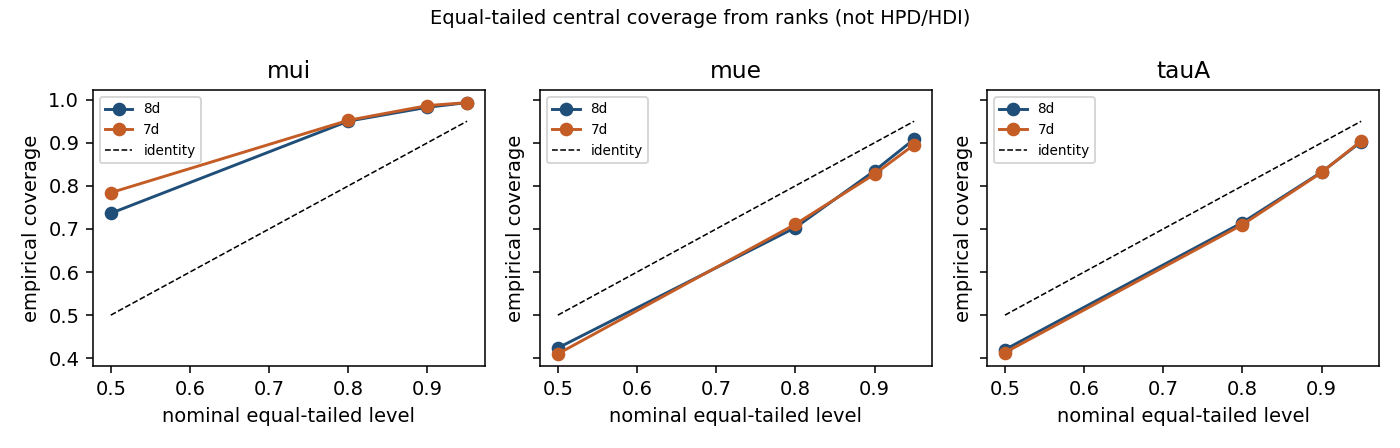

**phase1_8d32768_rank_mean_heatmap.png**

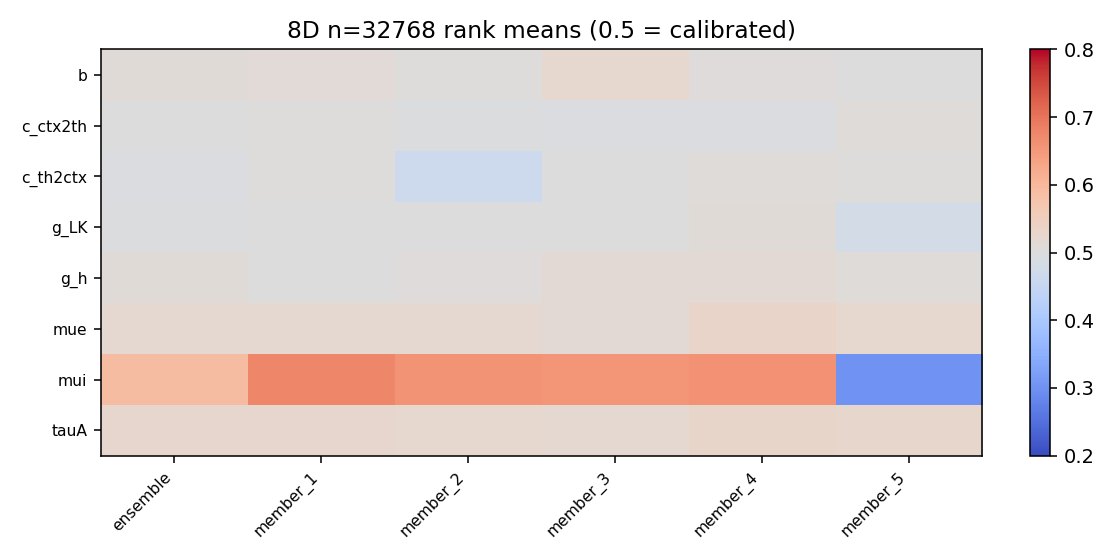

**phase1_8d_ensemble_pit_hist_focus.png**

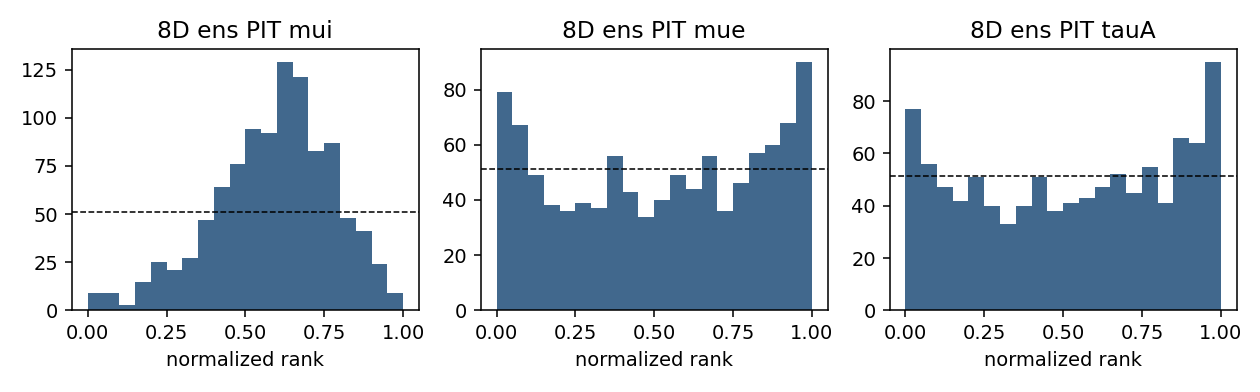

### Member direction / coverage consistency (≥3/5)

,track,parameter,n_members,rank_means,n_mean_below_045,n_mean_above_055,n_cov90_off_by_005,majority_3of5_direction,majority_3of5_cov_fail,mean_central_cov_90,mean_pit_ks
0,8d,mui,5,"[0.6744525006243756, 0.6584792160964036, 0.654...",1,4,0,True,False,0.940039,0.306017
1,8d,mue,5,"[0.5203917176573426, 0.5168464348151849, 0.512...",0,0,5,False,True,0.829492,0.074447
2,8d,tauA,5,"[0.5252111170079921, 0.5220258257367633, 0.520...",0,0,5,False,True,0.828320,0.075560
3,7d,mui,5,"[0.6323920220404595, 0.3320810049325674, 0.330...",3,2,1,True,False,0.931445,0.285790
4,7d,mue,5,"[0.5221058238636364, 0.5085061422952049, 0.525...",0,0,5,False,True,0.825977,0.074393
5,7d,tauA,5,"[0.5208268294205795, 0.5156084150224776, 0.519...",0,0,5,False,True,0.825977,0.072033


**Conclusion:** Focus parameters show stable cross-member calibration phenotype on the reused bank; 8192↔32768 remains an asymmetric descriptive contrast only.

In [4]:
from IPython.display import Image

for name in [
    "phase1_focus_central_coverage.png",
    "phase1_8d32768_rank_mean_heatmap.png",
    "phase1_8d_ensemble_pit_hist_focus.png",
]:
    path = FIG / name
    if path.is_file():
        display(Markdown(f"**{name}**"))
        display(Image(filename=str(path)))

cons = pd.read_csv(CSV / "phase1_direction_consistency.csv")
display(Markdown("### Member direction / coverage consistency (≥3/5)"))
display(cons)
display(Markdown(
    "**Conclusion:** Focus parameters show stable cross-member calibration phenotype on the reused bank; "
    "8192↔32768 remains an asymmetric descriptive contrast only."
))

## Phase 2 — Sampling / transform / clipping impact

Compare raw pre-clip vs clipped vs rejection-in-support on matched 48 cases. Material focus-param deltas → Decision A.

**Clip sensitivity:** `material`  
Focus exceedances: 54 / total exceedances: 137  
Missing sample jobs: 0  
Triggers Decision A: `True`

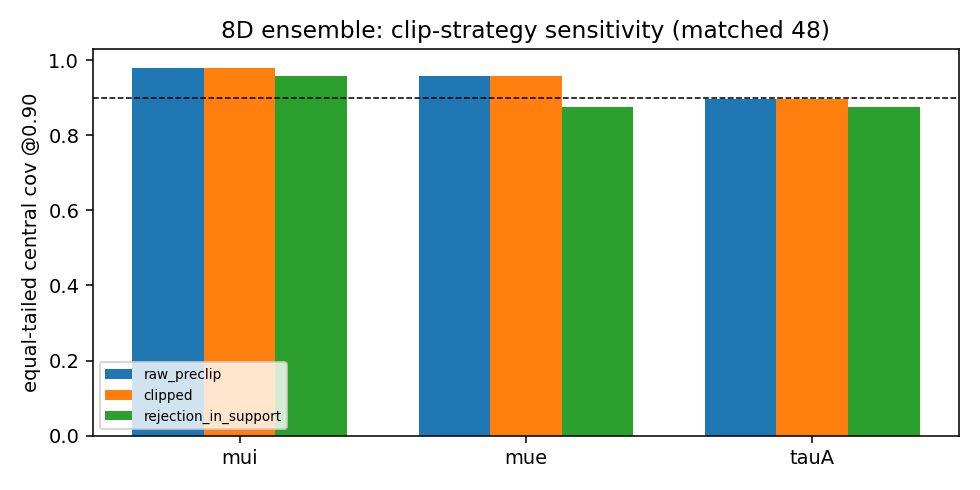

Focus exceedance rows: **54** (full table in artifacts CSV)

,track,member_key,parameter,strategy,metric,delta_vs_clipped,tolerance,exceeds_tolerance
5,8d,member_1,mue,rejection_in_support,pit_ecdf_ks,0.059820,0.05,True
6,8d,member_1,mue,rejection_in_support,central_cov_90,-0.062500,0.03,True
9,8d,member_1,mue,rejection_in_support,boundary_point_mass,-0.084920,0.02,True
36,8d,member_1,tauA,rejection_in_support,central_cov_90,-0.062500,0.03,True
39,8d,member_1,tauA,rejection_in_support,boundary_point_mass,-0.089844,0.02,True
86,8d,member_2,mue,rejection_in_support,central_cov_90,-0.083333,0.03,True
89,8d,member_2,mue,rejection_in_support,boundary_point_mass,-0.074626,0.02,True
96,8d,member_2,mui,rejection_in_support,central_cov_90,-0.041667,0.03,True
115,8d,member_2,tauA,rejection_in_support,pit_ecdf_ks,0.065058,0.05,True
119,8d,member_2,tauA,rejection_in_support,boundary_point_mass,-0.081055,0.02,True


**Gate:** FAIL → primary action A; do not attribute to summary/estimator/scale as main cause.

In [5]:
display(Markdown(
    f"**Clip sensitivity:** `{p2.get('clip_sensitivity')}`  \n"
    f"Focus exceedances: {p2.get('n_focus_exceedances')} / total exceedances: {p2.get('n_exceedances')}  \n"
    f"Missing sample jobs: {p2.get('jobs_missing')}  \n"
    f"Triggers Decision A: `{p2.get('triggers_decision_A')}`"
))
path = FIG / "phase2_clip_cov90_focus.png"
if path.is_file():
    from IPython.display import Image
    display(Image(filename=str(path)))
deltas = pd.read_csv(CSV / "phase2_strategy_deltas.csv")
focus_delta = deltas[(deltas.parameter.isin(["mui", "mue", "tauA"])) & (deltas.exceeds_tolerance)]
display(Markdown(f"Focus exceedance rows: **{len(focus_delta)}** (full table in artifacts CSV)"))
if len(focus_delta):
    display(focus_delta.head(20))
display(Markdown(
    "**Gate:** " + (
        "FAIL → primary action A; do not attribute to summary/estimator/scale as main cause."
        if p2.get("triggers_decision_A") or p0["integrity_gate"] != "PASS"
        else "PASS → proceed to Phase 3–4 attribution."
    )
))

## Phase 3 — Summary sensitivity / practical identifiability (OOF only)

Held-out/OOF metrics only. Low sensitivity indicates practical identifiability pressure, not a structural identifiability theorem.

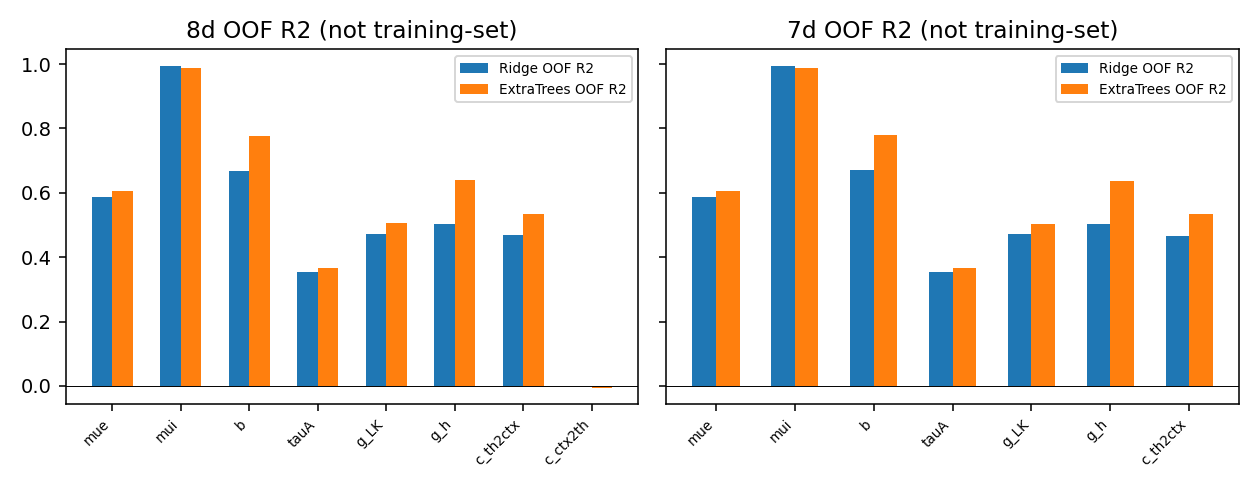

,track,parameter,oof_r2_ridge,oof_r2_extratrees,oof_r2_prior_mean_baseline,informative_vs_baseline,max_mi
0,7d,mue,0.585572,0.605681,-5.176876e-07,True,0.329134
1,8d,mue,0.586296,0.606522,-5.176876e-07,True,0.330826
2,7d,mui,0.995158,0.987385,-3.989140e-07,True,0.463805
3,8d,mui,0.995146,0.987178,-3.989140e-07,True,0.461061
4,7d,tauA,0.355359,0.367398,-6.821289e-06,True,0.183346
5,8d,tauA,0.355208,0.366296,-6.821289e-06,True,0.183594


**Guard:** low OOF R2 indicates weak summary informativeness / practical identifiability pressure only — it does not establish a structural identifiability theorem

In [6]:
if sens is None:
    display(Markdown("Phase 3 artifacts missing."))
else:
    path = FIG / "phase3_oof_r2.png"
    if path.is_file():
        from IPython.display import Image
        display(Image(filename=str(path)))
    focus_sens = sens[sens.parameter.isin(["mui", "mue", "tauA"])][
        ["track", "parameter", "oof_r2_ridge", "oof_r2_extratrees", "oof_r2_prior_mean_baseline", "informative_vs_baseline", "max_mi"]
    ]
    display(focus_sens.sort_values(["parameter", "track"]).reset_index(drop=True))
    display(Markdown(f"**Guard:** {p3.get('interpretation_guard', '')}"))

## Phase 4 — Gaussian-moment posterior consistency

Elliptical moment diagnostic $z = L^{-1}(\theta_{\mathrm{true}}-\mu)$ only. **Not** joint SBC; **not** general credible-region coverage.

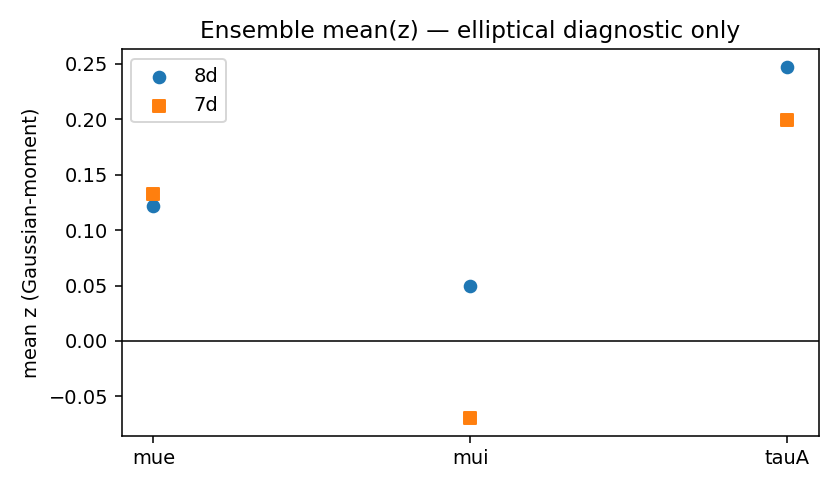

,track,parameter,mean_z,var_z,cov_z_frobenius_to_I,chol_failures
0,8d,mue,0.121591,0.815336,1.577126,0
1,8d,mui,0.049428,0.056875,1.577126,0
2,8d,tauA,0.247058,0.346243,1.577126,0
3,7d,mue,0.132132,0.854652,1.517924,0
4,7d,mui,-0.069718,0.072561,1.517924,0
5,7d,tauA,0.199396,0.246361,1.517924,0


**Guard:** True / Gaussian-moment diagnostic only; not joint SBC / general CR coverage

In [7]:
path = FIG / "phase4_mean_z_focus.png"
if path.is_file():
    from IPython.display import Image
    display(Image(filename=str(path)))
if (CSV / "phase4_gaussian_moment.csv").is_file():
    gm = pd.read_csv(CSV / "phase4_gaussian_moment.csv")
    sub = gm[(gm.member_key == "ensemble") & (gm.parameter.isin(["mui", "mue", "tauA"]))]
    display(sub[["track", "parameter", "mean_z", "var_z", "cov_z_frobenius_to_I", "chol_failures"]].reset_index(drop=True))
display(Markdown(f"**Guard:** {p4.get('not_general_credible_region_coverage', True)} / {gate.get('phase4_guard', '')}"))

## Phase 5 — Attribution matrix & final action table

In [8]:
display(Markdown(f"### Primary action: `{gate['primary_action']}`"))
display(Markdown("### Attribution Matrix"))
display(attr)
display(Markdown("### Final action GO / NO-GO"))
display(go)
display(Markdown(
    f"Simulator: **{gate.get('simulator_status')}** · "
    f"131k: **{gate.get('pilot_131k_status')}** · "
    f"1M: **{gate.get('scale_1M_status')}** · "
    f"Sealed bank required for final confirmation: **{gate.get('sealed_bank_required_for_final_confirmation')}**"
))

### Primary action: `A_IMPLEMENTATION_FIX_FIRST`

### Attribution Matrix

,candidate,support,against,uncertainty,strength,next_step_impact
0,A_implementation_sampling_clip,integrity failures or material clip deltas,NaN,CPU/GPU cross-check skipped if no GPU,moderate,fix transforms/sampling/ranks before any scien...
1,B_summary_identifiability,mixed,informative OOF signal,OOF≠structural; local compensation only,unresolved,summary redesign before scale-up if primary
2,C_estimator_calibration,stable ≥3/5 member coverage/rank failures with...,"if summaries uninformative, C is premature",diagnostic bank reuse; no sealed confirm,secondary_pending_A,calibration experiment / architecture — not tr...
3,D_data_scale,descriptive 8192↔32768 contrast only,no causal multi-seed scale design completed,high,not_primary,131k pilot design only if ABC not more urgent
4,E_inconclusive,NaN,NaN,default when gates ambiguous,NaN,minimal decisive offline experiment


### Final action GO / NO-GO

,work,go_status,reason
0,simulator / finite-difference,NO-GO,offline audit only; not authorized
1,retrain / new model,NO-GO,forbidden this round
2,controlled 131k multi-seed pilot design,NO-GO,A_IMPLEMENTATION_FIX_FIRST
3,1M scale-up,NO-GO,not justified; sealed bank required for final ...
4,summary redesign / identifiability work,HOLD,A_IMPLEMENTATION_FIX_FIRST
5,estimator calibration experiment,HOLD,A_IMPLEMENTATION_FIX_FIRST
6,implementation fix,GO,A_IMPLEMENTATION_FIX_FIRST


Simulator: **NO-GO** · 131k: **NO-GO** · 1M: **NO-GO** · Sealed bank required for final confirmation: **True**